# Método de Lattice-Boltzmann

* PET - Física UFRN
* Petianos: Wallysson Pereira da Silva
* Data: 13/09/2026

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Parâmetros de Simulação
Nx, Ny = 100, 100        # Resolução da grade
tau = 0.6                # Tempo de relaxação (relacionado à viscosidade)
Nt = 500                # Número de iterações
u_lid = 0.1              # Velocidade da tampa superior

# Pesos e direções do modelo D2Q9
NL = 9
idxs = np.arange(NL)
cxs = np.array([0, 0, 1, 0, -1, 1, -1, -1, 1])
cys = np.array([0, 1, 0, -1, 0, 1, 1, -1, -1])
weights = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36]) # Pesos de Lattice


In [11]:
# Inicialização
F = np.ones((Ny, Nx, NL)) # Função de distribuição de partículas
np.random.seed(42)
F += 0.01 * np.random.randn(Ny, Nx, NL) # Pequena perturbação inicial
X, Y = np.meshgrid(range(Nx), range(Ny))

# Máscaras de Contorno (Paredes)
cylinder = np.full((Ny, Nx), False)

In [12]:
u_x_values = []
u_y_values = []

# Loop Principal
for it in range(Nt):
    # 1. Variáveis Macroscópicas
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs, axis=2) / rho
    uy = np.sum(F * cys, axis=2) / rho

    # Condições de Contorno Macroscópicas (Tampa móvel)
    ux[0, :] = u_lid  # Parede superior movendo-se para a direita
    uy[0, :] = 0
    ux[:, 0] = 0; uy[:, 0] = 0   # Parede esquerda
    ux[:, -1] = 0; uy[:, -1] = 0 # Parede direita
    ux[-1, :] = 0; uy[-1, :] = 0 # Parede inferior
    
    # 2. Colisão (Equilíbrio e Relaxação BGK)
    Feq = np.zeros((Ny, Nx, NL))
    for i, cx, cy, w in zip(idxs, cxs, cys, weights):
        cu = 3 * (cx * ux + cy * uy)
        Feq[:, :, i] = rho * w * (1 + cu + 0.5 * cu**2 - 1.5 * (ux**2 + uy**2))
    
    F += -(1.0 / tau) * (F - Feq)
    
    # 3. Condição de Contorno Microcópica (Bounce-Back nas paredes estacionárias)
    for i, cx, cy in zip(idxs, cxs, cys):
        # Parede direita e esquerda
        F[:, 0, i] = Feq[:, 0, i]
        F[:, -1, i] = Feq[:, -1, i]
        # Parede inferior
        F[-1, :, i] = Feq[-1, :, i]
        # A parede superior já foi forçada pelas variáveis macroscópicas + Feq
        F[0, :, i] = Feq[0, :, i]

    # 4. Propagação (Streaming)
    for i, cx, cy in zip(idxs, cxs, cys):
        F[:, :, i] = np.roll(F[:, :, i], cx, axis=1)
        F[:, :, i] = np.roll(F[:, :, i], cy, axis=0)

    u_x_values.append(ux)
    u_y_values.append(uy)    
        

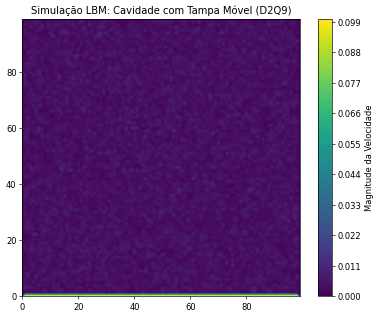

In [13]:
velocity = np.sqrt(u_x_values[0]**2 + u_y_values[0]**2)
fig, ax = plt.subplots(figsize=(8, 6), dpi=60)
contour = ax.contourf(X, Y, velocity, 100)
fig.colorbar(contour, ax=ax, label='Magnitude da Velocidade')
ax.set_title(f'Simulação LBM: Cavidade com Tampa Móvel (D2Q9)')
ax.set_aspect('equal')

def atualizar(frame):
    ax.clear()
    # Visualização da magnitude da velocidade
    velocity = np.sqrt(u_x_values[frame]**2 + u_y_values[frame]**2)
    contour = ax.contourf(X, Y, velocity, 100, cmap='inferno')
    fig.colorbar(contour, ax=ax, label='Magnitude da Velocidade')
    ax.set_title(f'Simulação LBM: Cavidade com Tampa Móvel (D2Q9)')
    ax.set_aspect('equal')

    return []

In [ ]:
anim = FuncAnimation(fig, atualizar, frames=Nt, interval=60, blit=True)
plt.close(fig) # Impede que o gráfico apareça como figura estática

caminho = '../Imagens/Boltzmann/Tampa_Movel.gif'
anim.save(caminho, writer='pillow')
plt.close(fig)

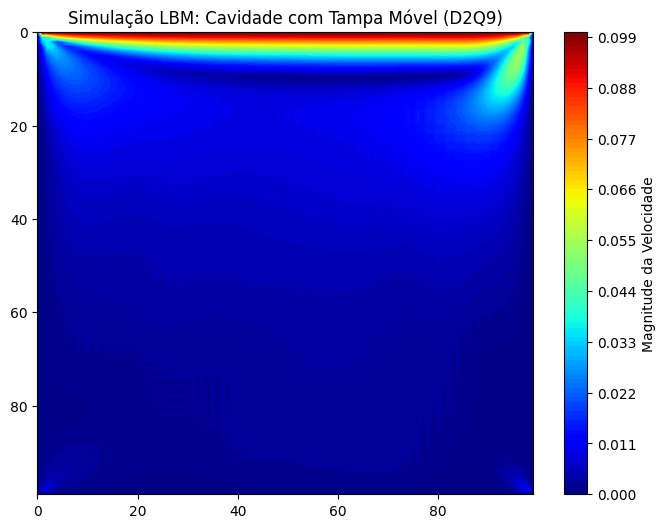

In [14]:
# Visualização da magnitude da velocidade
velocity = np.sqrt(ux**2 + uy**2)
plt.figure(figsize=(8,6))
plt.contourf(X, Y, velocity, 100, cmap='jet')
plt.colorbar(label='Magnitude da Velocidade')
plt.title('Simulação LBM: Cavidade com Tampa Móvel (D2Q9)')
plt.gca().invert_yaxis()
plt.show()

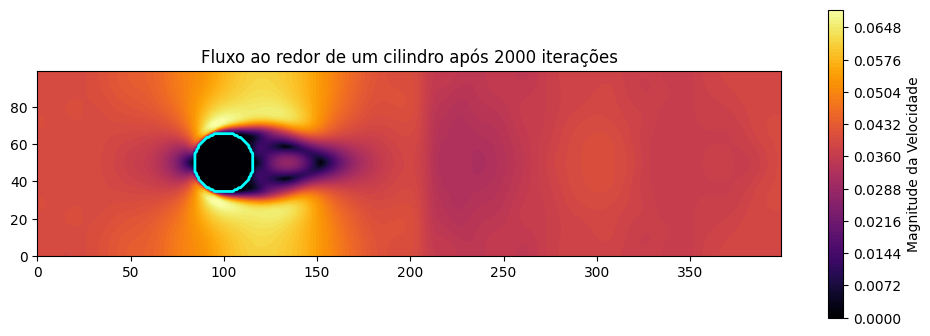

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros da Simulação
Nx, Ny = 400, 100        # Grade retangular (canal)
tau = 0.53               # Viscosidade baixa para permitir turbulência
Nt = 2000                # Número de passos de tempo
u_in = 0.04              # Velocidade de entrada do fluido

# Pesos e direções do modelo D2Q9
NL = 9
cxs = np.array([0, 0, 1, 0, -1, 1, -1, -1, 1])
cys = np.array([0, 1, 0, -1, 0, 1, 1, -1, -1])
weights = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36])

# Definindo o Obstáculo (Cilindro)
X, Y = np.meshgrid(range(Nx), range(Ny))
cylinder = (X - Nx//4)**2 + (Y - Ny//2)**2 < (Ny//6)**2

# Inicialização
rho = np.ones((Ny, Nx))
ux = np.full((Ny, Nx), u_in)
uy = np.zeros((Ny, Nx))
F = np.zeros((Ny, Nx, NL))

# Função de Equilíbrio (usada na inicialização e na colisão)
def equilibrium(rho, ux, uy):
    Feq = np.zeros((Ny, Nx, NL))
    u_sq = ux**2 + uy**2
    for i, cx, cy, w in zip(range(NL), cxs, cys, weights):
        cu = cx * ux + cy * uy
        Feq[:, :, i] = rho * w * (1 + 3*cu + 4.5*cu**2 - 1.5*u_sq)
    return Feq

F = equilibrium(rho, ux, uy)

# Loop Principal LBM
for it in range(Nt):
    # Condição de Contorno: Entrada de fluxo constante à esquerda
    for i, cx, cy, w in zip(range(NL), cxs, cys, weights):
        if cx > 0:
            F[:, 0, i] = w * (1 + 3*u_in + 4.5*u_in**2 - 1.5*u_in**2)

    # Propagação (Streaming)
    for i, cx, cy in zip(range(NL), cxs, cys):
        F[:, :, i] = np.roll(F[:, :, i], cx, axis=1)
        F[:, :, i] = np.roll(F[:, :, i], cy, axis=0)
        
    # Bounce-back no cilindro
    bndryF = F[cylinder, :]
    bndryF = bndryF[:, [0, 3, 4, 1, 2, 7, 8, 5, 6]] # Inverte as direções
    
    # Variáveis Macroscópicas
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs, axis=2) / rho
    uy = np.sum(F * cys, axis=2) / rho
    
    # Aplica velocidade zero dentro do obstáculo
    ux[cylinder] = 0
    uy[cylinder] = 0
    rho[cylinder] = 1
    
    # Colisão BGK
    Feq = equilibrium(rho, ux, uy)
    F += -(1.0 / tau) * (F - Feq)
    
    # Reaplica as partículas refletidas pelo obstáculo
    F[cylinder, :] = bndryF

# Visualização do campo de velocidade (Vorticidade ou Magnitude)
velocity = np.sqrt(ux**2 + uy**2)
velocity[cylinder] = 0

plt.figure(figsize=(12, 4))
plt.contourf(X, Y, velocity, 100, cmap='inferno')
plt.colorbar(label='Magnitude da Velocidade')
# Desenhando o contorno do cilindro
plt.contour(X, Y, cylinder, levels=[0.5], colors='cyan', linewidths=2)
plt.title(f'Fluxo ao redor de um cilindro após {Nt} iterações')
plt.gca().set_aspect('equal')
plt.show()